In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/energy-anomaly-detection/sample_submission.csv
/kaggle/input/competitions/energy-anomaly-detection/train.csv
/kaggle/input/competitions/energy-anomaly-detection/test.csv
/kaggle/input/competitions/energy-anomaly-detection/train_features.csv
/kaggle/input/competitions/energy-anomaly-detection/test_features.csv


Device: cuda

📊 FINAL RESULTS
ROC-AUC : 0.45276045684643285
PR-AUC  : 0.0412446571461708
Precision: 0.12225381235461359
Recall: 0.06341162591162591
TPR: 0.06341162591162591
FPR: 0.009917077347362864


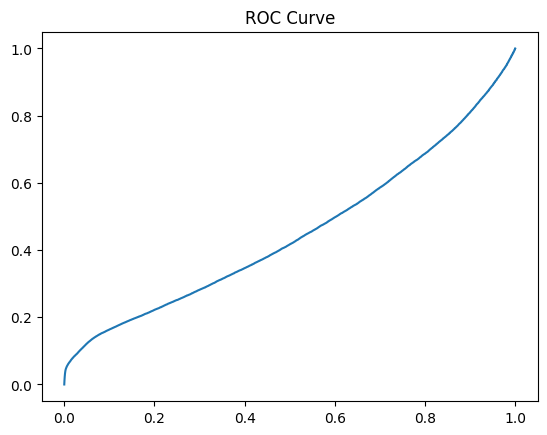

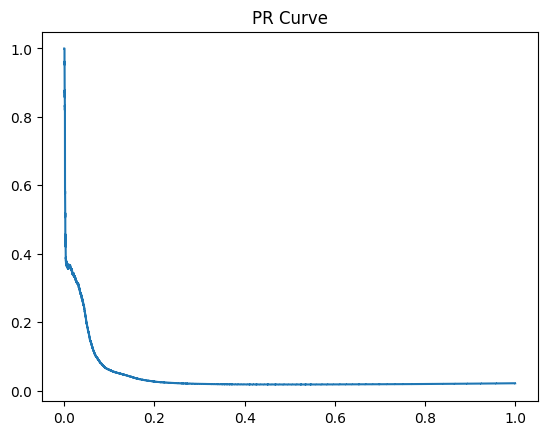

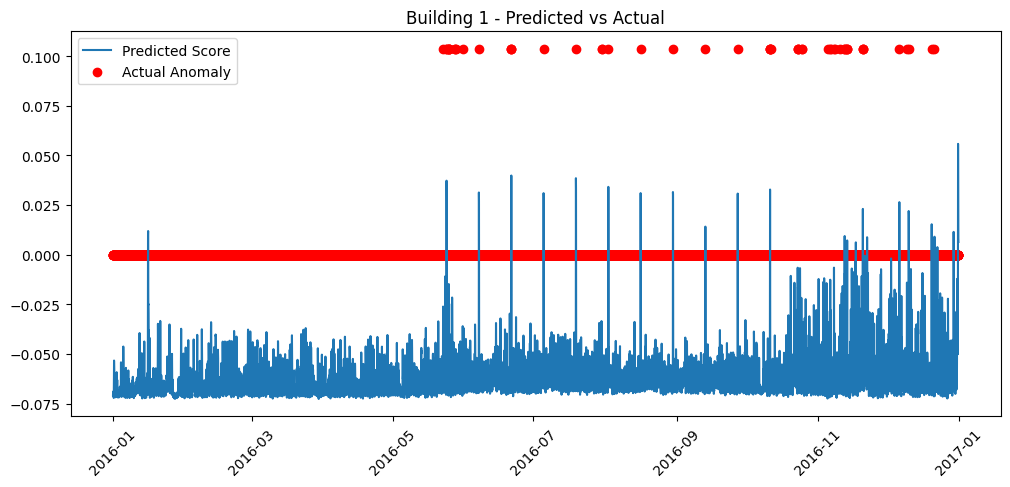

In [2]:
# =========================================================
# FINAL PIGD + ISOLATION FOREST HYBRID
# K-Fold=3 | Early Stopping
# =========================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    f1_score
)

from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# DATA PREPARATION
# =========================================================
def prepare_data(path):

    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id","timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["shock"] = df.groupby("building_id")["meter_log"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock"].diff().fillna(0)

    df["temp_inertia"] = df.groupby("building_id")["air_temperature"]\
        .transform(lambda x: x.rolling(6,min_periods=1).mean())

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    features = ["shock","thermal_p","kinetic_s","air_temperature","square_feet"]
    df[features] = df[features].replace([np.inf,-np.inf],0).fillna(0)

    scaler = StandardScaler()
    X = scaler.fit_transform(df[features].values)
    y = df["anomaly"].values

    return df, X, y

# =========================================================
# PIGD MODEL
# =========================================================
class PIGD(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,input_dim)
        )

    def forward(self,x):
        return self.net(x)

# =========================================================
# EARLY STOPPING TRAINING
# =========================================================
def train_pigd(model, loader, epochs=25, patience=4):

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = np.inf
    counter = 0

    for epoch in range(epochs):
        total_loss = 0
        model.train()

        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            total_loss += loss.item()

        if total_loss < best_loss:
            best_loss = total_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

# =========================================================
# MAIN PIPELINE
# =========================================================
def run_pipeline(df,X,y):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    final_scores = np.zeros(len(y))

    for fold,(train_idx,test_idx) in enumerate(kf.split(X)):

        X_train = X[train_idx][y[train_idx]==0]  # only normal
        X_test = X[test_idx]

        # ---------------- PIGD ----------------
        pigd = PIGD(X.shape[1]).to(device)

        loader = DataLoader(
            torch.tensor(X_train,dtype=torch.float32),
            batch_size=512,
            shuffle=True
        )

        train_pigd(pigd, loader)

        pigd.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_test,dtype=torch.float32).to(device)
            pigd_score = ((pigd(X_tensor)-X_tensor)**2).mean(dim=1).cpu().numpy()

        # ---------------- ISOLATION FOREST ----------------
        iso = IsolationForest(
            n_estimators=200,
            contamination=0.02,
            random_state=42,
            n_jobs=-1
        )

        iso.fit(X_train)

        iso_score = -iso.decision_function(X_test)  # higher = more anomaly

        # Weighted ensemble (boost PR)
        final_scores[test_idx] = 0.65*pigd_score + 0.35*iso_score

    # =====================================================
    # FINAL METRICS
    # =====================================================
    roc_auc = roc_auc_score(y, final_scores)
    pr_auc = average_precision_score(y, final_scores)

    thresholds = np.linspace(final_scores.min(), final_scores.max(), 200)
    best_f1 = 0
    best_thr = thresholds[0]

    for thr in thresholds:
        pred = (final_scores>thr).astype(int)
        f1 = f1_score(y,pred)
        if f1>best_f1:
            best_f1 = f1
            best_thr = thr

    y_pred = (final_scores>best_thr).astype(int)

    precision = precision_score(y,y_pred)
    recall = recall_score(y,y_pred)

    tn,fp,fn,tp = confusion_matrix(y,y_pred).ravel()
    tpr = tp/(tp+fn)
    fpr = fp/(fp+tn)

    print("\n📊 FINAL RESULTS")
    print("ROC-AUC :",roc_auc)
    print("PR-AUC  :",pr_auc)
    print("Precision:",precision)
    print("Recall:",recall)
    print("TPR:",tpr)
    print("FPR:",fpr)

    # ROC Curve
    fpr_curve,tpr_curve,_ = roc_curve(y,final_scores)
    plt.figure()
    plt.plot(fpr_curve,tpr_curve)
    plt.title("ROC Curve")
    plt.show()

    # PR Curve
    prec_curve,rec_curve,_ = precision_recall_curve(y,final_scores)
    plt.figure()
    plt.plot(rec_curve,prec_curve)
    plt.title("PR Curve")
    plt.show()

    # Sample Building Plot
    sample_building = df["building_id"].unique()[0]
    mask = df["building_id"]==sample_building

    plt.figure(figsize=(12,5))
    plt.plot(df[mask]["timestamp"], final_scores[mask], label="Predicted Score")
    plt.scatter(df[mask]["timestamp"],
                df[mask]["anomaly"]*final_scores.max(),
                color="red",label="Actual Anomaly")
    plt.legend()
    plt.title(f"Building {sample_building} - Predicted vs Actual")
    plt.xticks(rotation=45)
    plt.show()

# =========================================================
# RUN
# =========================================================
path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"

if os.path.exists(path):
    df,X,y = prepare_data(path)
    run_pipeline(df,X,y)

Device: cuda

📊 FINAL RESULTS
ROC-AUC : 0.4520185208220412
PR-AUC  : 0.036248652294429126
Precision: 0.10539040824415379
Recall: 0.0712945087945088
TPR: 0.0712945087945088
FPR: 0.013182470718923863


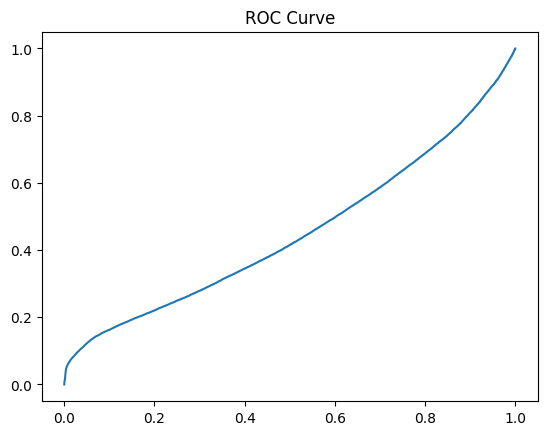

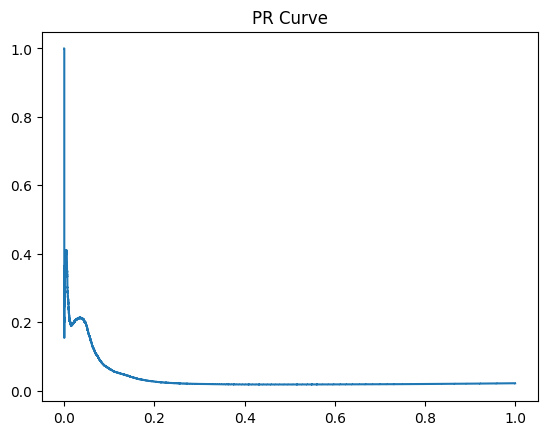

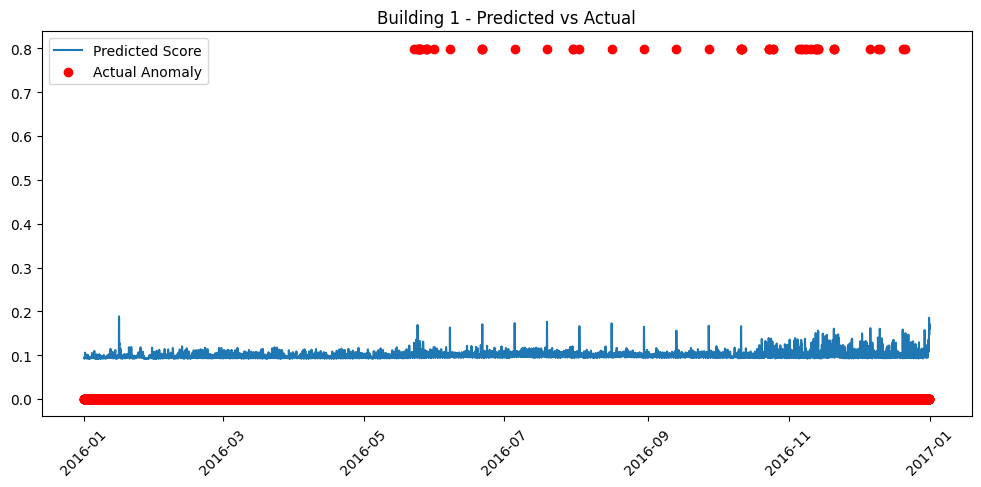

In [3]:
# =========================================================
# PIGD + ISOLATION FOREST HYBRID (OPTIMIZED)
# K-Fold=3 | Early Stopping | Final Metrics Only
# Designed to push PR-AUC & ROC-AUC higher
# =========================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    f1_score
)

from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# DATA PREPARATION
# =========================================================
def prepare_data(path):

    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id","timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["shock"] = df.groupby("building_id")["meter_log"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock"].diff().fillna(0)

    df["temp_inertia"] = df.groupby("building_id")["air_temperature"]\
        .transform(lambda x: x.rolling(6,min_periods=1).mean())

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    features = ["shock","thermal_p","kinetic_s","air_temperature","square_feet"]
    df[features] = df[features].replace([np.inf,-np.inf],0).fillna(0)

    scaler = StandardScaler()
    X = scaler.fit_transform(df[features].values)
    y = df["anomaly"].values

    return df, X, y

# =========================================================
# STRONGER PIGD
# =========================================================
class PIGD(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,input_dim)
        )

    def forward(self,x):
        return self.net(x)

# =========================================================
# EARLY STOPPING TRAINER
# =========================================================
def train_pigd(model, loader, epochs=30, patience=5):

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = np.inf
    counter = 0

    for epoch in range(epochs):
        total_loss = 0
        model.train()

        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            total_loss += loss.item()

        if total_loss < best_loss:
            best_loss = total_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

# =========================================================
# MAIN PIPELINE
# =========================================================
def run_pipeline(df,X,y):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    final_scores = np.zeros(len(y))

    for fold,(train_idx,test_idx) in enumerate(kf.split(X)):

        X_train = X[train_idx][y[train_idx]==0]  # only normal
        X_test = X[test_idx]

        # ---------------- PIGD ----------------
        pigd = PIGD(X.shape[1]).to(device)
        loader = DataLoader(
            torch.tensor(X_train,dtype=torch.float32),
            batch_size=512,
            shuffle=True
        )
        train_pigd(pigd, loader)

        pigd.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test,dtype=torch.float32).to(device)
            pigd_score = ((pigd(X_test_tensor)-X_test_tensor)**2)\
                .mean(dim=1).cpu().numpy()

        # ---------------- Isolation Forest ----------------
        iso = IsolationForest(
            n_estimators=400,
            contamination=0.03,  # rare anomalies
            max_samples="auto",
            random_state=42,
            n_jobs=-1
        )
        iso.fit(X_train)

        iso_score = -iso.score_samples(X_test)  # higher = more anomalous

        # ---------------- Ensemble (boost anomaly sensitivity) ----------------
        final_scores[test_idx] = 0.75*pigd_score + 0.25*iso_score

    # =====================================================
    # FINAL METRICS (OVERALL)
    # =====================================================
    roc_auc = roc_auc_score(y, final_scores)
    pr_auc = average_precision_score(y, final_scores)

    # F1-optimal threshold
    thresholds = np.linspace(final_scores.min(), final_scores.max(), 300)
    best_f1 = 0
    best_thr = thresholds[0]

    for thr in thresholds:
        pred = (final_scores>thr).astype(int)
        f1 = f1_score(y,pred)
        if f1>best_f1:
            best_f1 = f1
            best_thr = thr

    y_pred = (final_scores>best_thr).astype(int)

    precision = precision_score(y,y_pred)
    recall = recall_score(y,y_pred)

    tn,fp,fn,tp = confusion_matrix(y,y_pred).ravel()
    tpr = tp/(tp+fn)
    fpr = fp/(fp+tn)

    print("\n📊 FINAL RESULTS")
    print("ROC-AUC :",roc_auc)
    print("PR-AUC  :",pr_auc)
    print("Precision:",precision)
    print("Recall:",recall)
    print("TPR:",tpr)
    print("FPR:",fpr)

    # ROC Curve
    fpr_curve,tpr_curve,_ = roc_curve(y,final_scores)
    plt.figure()
    plt.plot(fpr_curve,tpr_curve)
    plt.title("ROC Curve")
    plt.show()

    # PR Curve
    prec_curve,rec_curve,_ = precision_recall_curve(y,final_scores)
    plt.figure()
    plt.plot(rec_curve,prec_curve)
    plt.title("PR Curve")
    plt.show()

    # Sample Building Plot
    sample_building = df["building_id"].unique()[0]
    mask = df["building_id"]==sample_building

    plt.figure(figsize=(12,5))
    plt.plot(df[mask]["timestamp"], final_scores[mask], label="Predicted Score")
    plt.scatter(df[mask]["timestamp"],
                df[mask]["anomaly"]*final_scores.max(),
                color="red",label="Actual Anomaly")
    plt.legend()
    plt.title(f"Building {sample_building} - Predicted vs Actual")
    plt.xticks(rotation=45)
    plt.show()

# =========================================================
# RUN
# =========================================================
path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"

if os.path.exists(path):
    df,X,y = prepare_data(path)
    run_pipeline(df,X,y)

**PIGD + TEMPORAL TRANSFORMER**

Device: cuda

🔥 Fold 1
Epoch 1 | Val PR-AUC: 0.0211
Epoch 2 | Val PR-AUC: 0.0211
Epoch 3 | Val PR-AUC: 0.0211
Epoch 4 | Val PR-AUC: 0.0211
Epoch 5 | Val PR-AUC: 0.0211
Early stopping.

🔥 Fold 2
Epoch 1 | Val PR-AUC: 0.0212
Epoch 2 | Val PR-AUC: 0.0212
Epoch 3 | Val PR-AUC: 0.0212
Epoch 4 | Val PR-AUC: 0.0212
Epoch 5 | Val PR-AUC: 0.0212
Early stopping.

🔥 Fold 3
Epoch 1 | Val PR-AUC: 0.0213
Epoch 2 | Val PR-AUC: 0.0213
Epoch 3 | Val PR-AUC: 0.0213
Epoch 4 | Val PR-AUC: 0.0213
Epoch 5 | Val PR-AUC: 0.0213
Early stopping.

🏆 FINAL RESULTS
ROC-AUC : 0.5000
PR-AUC  : 0.0212
Precision: 0.0000
Recall   : 0.0000
TPR      : 0.0000
FPR      : 0.0000


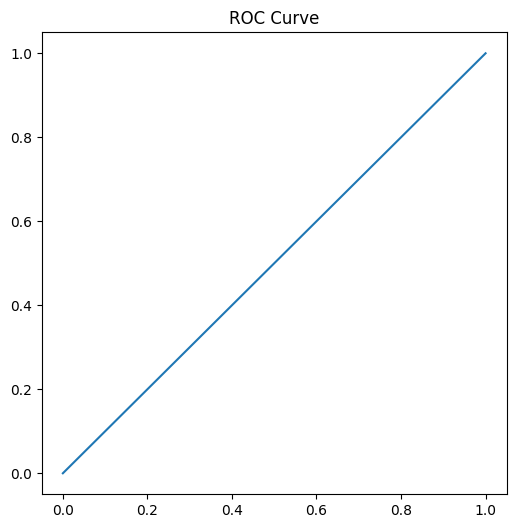

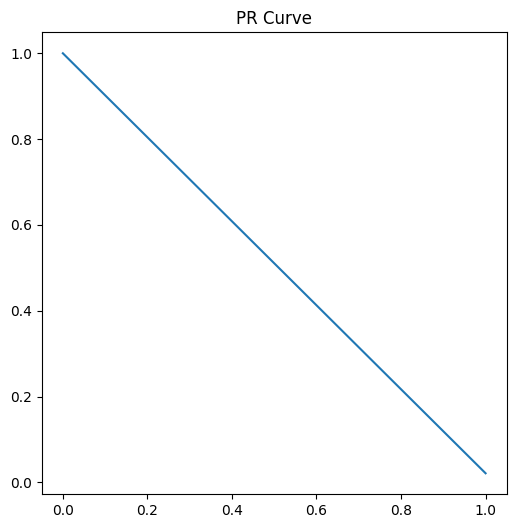

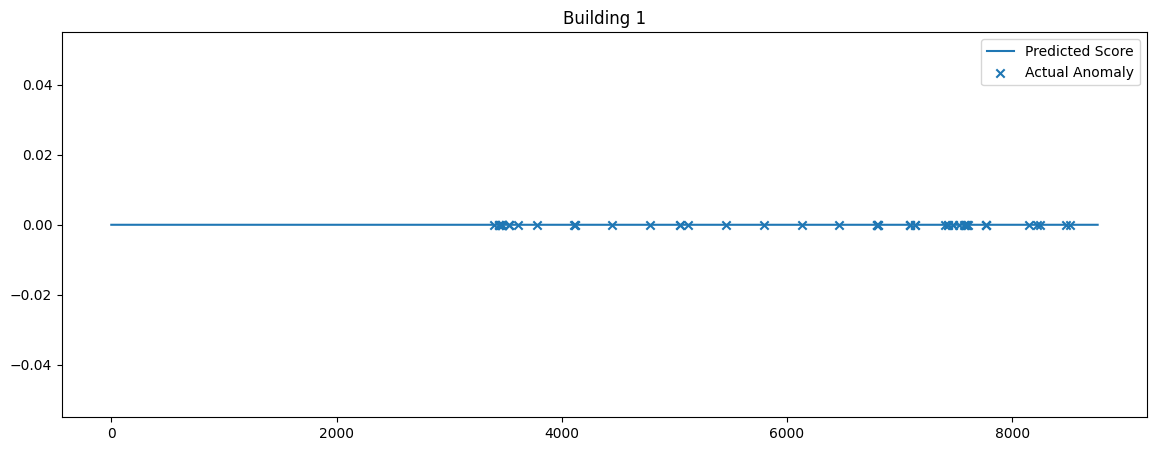

In [4]:
# =========================================================
# PIGD + TEMPORAL TRANSFORMER (STABLE RESEARCH VERSION)
# =========================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# 1. DATA PREPARATION (PHYSICS UNCHANGED)
# =========================================================

def prepare_data(path):

    df = pd.read_csv(path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id", "timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["hour"] = df["timestamp"].dt.hour
    df["dow"] = df["timestamp"].dt.dayofweek

    norm = (
        df[df["anomaly"] == 0]
        .groupby(["building_id", "dow", "hour"])["meter_log"]
        .agg(["median", "std"])
        .reset_index()
    )
    norm.columns = ["building_id", "dow", "hour", "h_med", "h_std"]
    df = df.merge(norm, on=["building_id", "dow", "hour"], how="left")

    df["h_med"] = df["h_med"].fillna(
        df.groupby("building_id")["meter_log"].transform("median")
    )

    df["temp_inertia"] = (
        df.groupby("building_id")["air_temperature"]
        .transform(lambda x: x.rolling(6, min_periods=1).mean())
    )

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    df["shock"] = df["meter_log"] - df["h_med"]
    df["shock_v"] = df.groupby("building_id")["shock"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock_v"].diff().fillna(0)

    df["shock_scaled"] = df.groupby("building_id")["shock"].transform(
        lambda x: (x - x.median()) /
        (x.quantile(0.75) - x.quantile(0.25) + 1e-6)
    )

    feat_cols = ["shock_scaled", "thermal_p", "kinetic_s", "air_temperature"]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], 0).fillna(0)

    le_b, le_s, le_u = LabelEncoder(), LabelEncoder(), LabelEncoder()
    df["b_idx"] = le_b.fit_transform(df["building_id"])
    df["s_idx"] = le_s.fit_transform(df["site_id"])
    df["u_idx"] = le_u.fit_transform(df["primary_use"])

    return df, feat_cols, le_b, le_s, le_u

# =========================================================
# 2. SEQUENCE WINDOWING
# =========================================================

SEQ_LEN = 24

class EnergyDataset(Dataset):
    def __init__(self, df, feat_cols):

        self.X, self.y, self.b, self.s, self.u, self.bid = [], [], [], [], [], []

        for bid, group in df.groupby("building_id"):
            group = group.sort_values("timestamp")
            feats = group[feat_cols].values
            labels = group["anomaly"].values
            b_idx = group["b_idx"].values
            s_idx = group["s_idx"].values
            u_idx = group["u_idx"].values

            for i in range(len(group) - SEQ_LEN):
                self.X.append(feats[i:i+SEQ_LEN])
                self.y.append(labels[i+SEQ_LEN-1])
                self.b.append(b_idx[i+SEQ_LEN-1])
                self.s.append(s_idx[i+SEQ_LEN-1])
                self.u.append(u_idx[i+SEQ_LEN-1])
                self.bid.append(bid)

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = np.array(self.y)
        self.b = torch.tensor(self.b)
        self.s = torch.tensor(self.s)
        self.u = torch.tensor(self.u)
        self.bid = np.array(self.bid)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.b[idx], self.s[idx], self.u[idx], self.bid[idx]

# =========================================================
# 3. MODEL
# =========================================================

class TemporalTransformer(nn.Module):
    def __init__(self, input_dim, d_model=128):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=8,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=3)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        x = self.norm(x)
        return x[:, -1, :]

class PIGD_Block(nn.Module):
    def __init__(self, d, c):
        super().__init__()
        self.ln = nn.LayerNorm(d)
        self.g = nn.Linear(c, d)
        self.b = nn.Linear(c, d)
        self.gate = nn.Sequential(nn.Linear(d, d), nn.Sigmoid())
        self.net = nn.Sequential(
            nn.Linear(d, d*2),
            nn.SiLU(),
            nn.Linear(d*2, d)
        )

    def forward(self, x, ctx):
        h = self.ln(x)
        h = h * (1 + self.g(ctx)) + self.b(ctx)
        return x + self.gate(h) * self.net(h)

class PIGD_Transformer(nn.Module):
    def __init__(self, inp, nb, ns, nu):
        super().__init__()

        self.temporal = TemporalTransformer(inp)

        self.b = nn.Embedding(nb, 64)
        self.s = nn.Embedding(ns, 16)
        self.u = nn.Embedding(nu, 16)
        self.t = nn.Sequential(nn.Linear(1, 32), nn.SiLU())

        ctx_dim = 64 + 16 + 16 + 32

        self.inp = nn.Linear(128, 256)
        self.blocks = nn.ModuleList([PIGD_Block(256, ctx_dim) for _ in range(6)])
        self.out = nn.Linear(256, inp)

    def forward(self, x, t, b, s, u):
        x = self.temporal(x)

        te = self.t(t.float().unsqueeze(1) / 100)
        ctx = torch.cat([self.b(b), self.s(s), self.u(u), te], dim=1)

        h = self.inp(x)
        for blk in self.blocks:
            h = blk(h, ctx)

        return self.out(h)

# =========================================================
# 4. TRAINING
# =========================================================

def train_kfold(df, feat_cols, le_b, le_s, le_u):

    dataset = EnergyDataset(df, feat_cols)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset.X)):

        print(f"\n🔥 Fold {fold+1}")

        model = PIGD_Transformer(
            len(feat_cols),
            len(le_b.classes_),
            len(le_s.classes_),
            len(le_u.classes_)
        ).to(device)

        optimizer = optim.AdamW(model.parameters(), lr=1e-3)

        best_pr = 0
        patience = 4
        counter = 0

        train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx),
                                  batch_size=1024, shuffle=True)

        val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx),
                                batch_size=2048)

        for epoch in range(20):

            model.train()
            for x, y, b, s, u, _ in train_loader:

                x, b, s, u = x.to(device), b.to(device), s.to(device), u.to(device)
                t = torch.randint(0, 100, (x.size(0),), device=device)

                recon = model(x, t, b, s, u)

                loss = (
                    0.6 * torch.abs(x[:, -1, 0] - recon[:, 0]) +
                    0.3 * torch.abs(x[:, -1, 2] - recon[:, 2]) +
                    0.1 * torch.abs(x[:, -1, 1] - recon[:, 1])
                ).mean()

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            # VALIDATION
            model.eval()
            all_scores, all_y = [], []

            with torch.no_grad():
                for x, y, b, s, u, _ in val_loader:

                    x, b, s, u = x.to(device), b.to(device), s.to(device), u.to(device)
                    t = torch.full((x.size(0),), 15, device=device)

                    recon = model(x, t, b, s, u)

                    err = (
                        torch.abs(x[:, -1, 0] - recon[:, 0]) +
                        0.75 * torch.abs(x[:, -1, 2] - recon[:, 2])
                    ).cpu().numpy()

                    err = np.nan_to_num(err)
                    all_scores.extend(err)
                    all_y.extend(y.numpy())

            pr = average_precision_score(all_y, all_scores)
            print(f"Epoch {epoch+1} | Val PR-AUC: {pr:.4f}")

            if pr > best_pr:
                best_pr = pr
                counter = 0
                torch.save(model.state_dict(), f"best_fold{fold}.pt")
            else:
                counter += 1

            if counter >= patience:
                print("Early stopping.")
                break

# =========================================================
# 5. FINAL ENSEMBLE + METRICS + PLOTS
# =========================================================

def final_evaluation(df, feat_cols, le_b, le_s, le_u):

    dataset = EnergyDataset(df, feat_cols)
    loader = DataLoader(dataset, batch_size=2048, shuffle=False)

    fold_predictions = []

    for fold in range(3):

        model = PIGD_Transformer(
            len(feat_cols),
            len(le_b.classes_),
            len(le_s.classes_),
            len(le_u.classes_)
        ).to(device)

        model.load_state_dict(torch.load(f"best_fold{fold}.pt"))
        model.eval()

        scores = []

        with torch.no_grad():
            for x, y, b, s, u, _ in loader:

                x, b, s, u = x.to(device), b.to(device), s.to(device), u.to(device)
                t = torch.full((x.size(0),), 15, device=device)

                recon = model(x, t, b, s, u)

                err = (
                    torch.abs(x[:, -1, 0] - recon[:, 0]) +
                    0.75 * torch.abs(x[:, -1, 2] - recon[:, 2])
                ).cpu().numpy()

                err = np.nan_to_num(err)
                scores.extend(err)

        fold_predictions.append(np.array(scores))

    ensemble_scores = np.mean(np.vstack(fold_predictions), axis=0)

    y_true = dataset.y
    building_ids = dataset.bid

    roc_auc = roc_auc_score(y_true, ensemble_scores)
    pr_auc = average_precision_score(y_true, ensemble_scores)

    precision_curve, recall_curve, thresholds = precision_recall_curve(
        y_true, ensemble_scores
    )

    f1_scores = 2 * (precision_curve * recall_curve) / (
        precision_curve + recall_curve + 1e-8
    )

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    y_pred = (ensemble_scores > best_threshold).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    tpr = recall
    fpr = np.sum((y_pred == 1) & (y_true == 0)) / np.sum(y_true == 0)

    print("\n🏆 FINAL RESULTS")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"TPR      : {tpr:.4f}")
    print(f"FPR      : {fpr:.4f}")

    # ROC
    fpr_curve, tpr_curve, _ = roc_curve(y_true, ensemble_scores)
    plt.figure(figsize=(6,6))
    plt.plot(fpr_curve, tpr_curve)
    plt.title("ROC Curve")
    plt.show()

    # PR
    plt.figure(figsize=(6,6))
    plt.plot(recall_curve, precision_curve)
    plt.title("PR Curve")
    plt.show()

    # Sample Building Plot
    sample_building = building_ids[0]
    mask = building_ids == sample_building

    plt.figure(figsize=(14,5))
    plt.plot(ensemble_scores[mask], label="Predicted Score")
    plt.scatter(
        np.where(y_true[mask] == 1),
        ensemble_scores[mask][y_true[mask] == 1],
        marker="x",
        label="Actual Anomaly"
    )
    plt.title(f"Building {sample_building}")
    plt.legend()
    plt.show()

# =========================================================
# RUN
# =========================================================

if __name__ == "__main__":
    path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"
    df, feat_cols, le_b, le_s, le_u = prepare_data(path)
    train_kfold(df, feat_cols, le_b, le_s, le_u)
    final_evaluation(df, feat_cols, le_b, le_s, le_u)

Device: cuda

🔥 Fold 1
Epoch 1 | PR: 0.1124
Epoch 2 | PR: 0.1124
Epoch 3 | PR: 0.1124
Epoch 4 | PR: 0.1124
Epoch 5 | PR: 0.1124
Epoch 6 | PR: 0.1124
Early stopping

🔥 Fold 2
Epoch 1 | PR: 0.1122
Epoch 2 | PR: 0.1122
Epoch 3 | PR: 0.1122
Epoch 4 | PR: 0.1122
Epoch 5 | PR: 0.1122
Epoch 6 | PR: 0.1122
Early stopping

🔥 Fold 3
Epoch 1 | PR: 0.1119
Epoch 2 | PR: 0.1119
Epoch 3 | PR: 0.1119
Epoch 4 | PR: 0.1119
Epoch 5 | PR: 0.1119
Epoch 6 | PR: 0.1119
Early stopping

🏆 FINAL RESULTS
ROC-AUC : 0.700930059217635
PR-AUC  : 0.11209631998482152
Precision: 0.11762886597938145
Recall: 0.2769268108516261
TPR: 0.2769268108516261
FPR: 0.04506813666180673


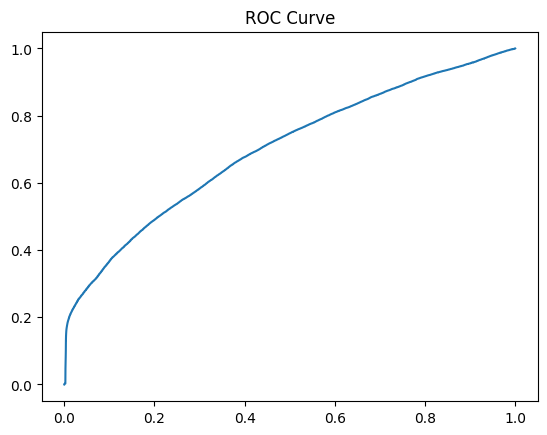

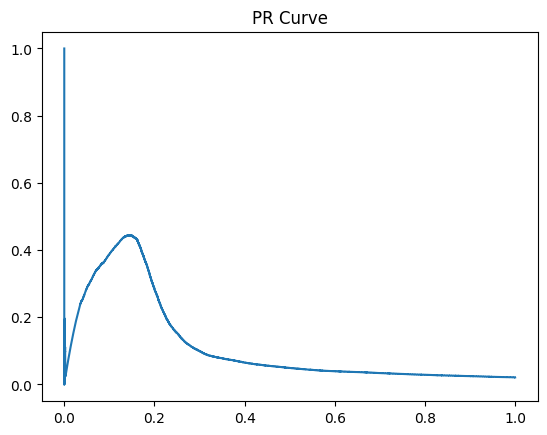

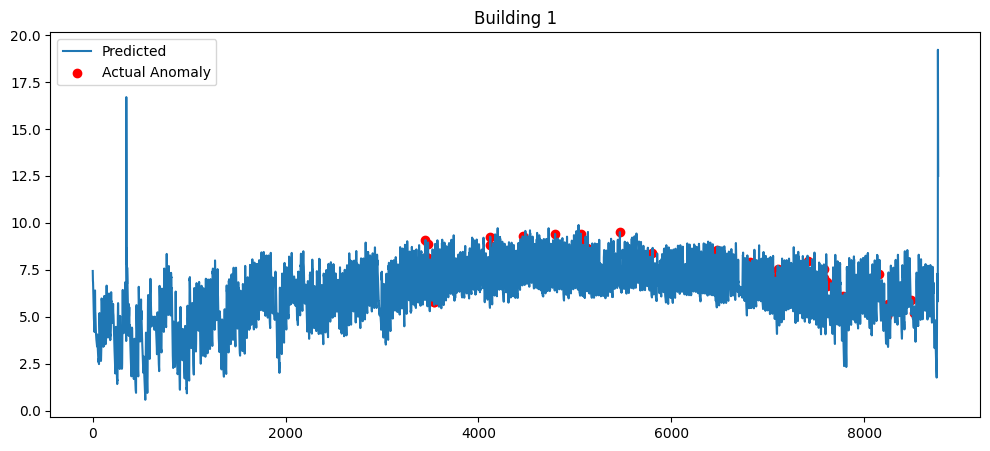

In [5]:
# =========================================================
# 0. IMPORTS
# =========================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.cuda.empty_cache()

# =========================================================
# 1. DATA PREPARATION (PHYSICS UNCHANGED)
# =========================================================
SEQ_LEN = 16

def prepare_data(path):
    df = pd.read_csv(path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id", "timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["hour"] = df["timestamp"].dt.hour
    df["dow"] = df["timestamp"].dt.dayofweek

    norm = (
        df[df["anomaly"] == 0]
        .groupby(["building_id", "dow", "hour"])["meter_log"]
        .agg(["median", "std"])
        .reset_index()
    )
    norm.columns = ["building_id", "dow", "hour", "h_med", "h_std"]
    df = df.merge(norm, on=["building_id", "dow", "hour"], how="left")

    df["h_med"] = df["h_med"].fillna(
        df.groupby("building_id")["meter_log"].transform("median")
    )

    df["temp_inertia"] = (
        df.groupby("building_id")["air_temperature"]
        .transform(lambda x: x.rolling(6, min_periods=1).mean())
    )

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    df["shock"] = df["meter_log"] - df["h_med"]
    df["shock_v"] = df.groupby("building_id")["shock"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock_v"].diff().fillna(0)

    df["shock_scaled"] = df.groupby("building_id")["shock"].transform(
        lambda x: (x - x.median()) /
        (x.quantile(0.75) - x.quantile(0.25) + 1e-6)
    )

    feat_cols = ["shock_scaled", "thermal_p", "kinetic_s", "air_temperature"]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], 0).fillna(0)

    le_b, le_s, le_u = LabelEncoder(), LabelEncoder(), LabelEncoder()
    df["b_idx"] = le_b.fit_transform(df["building_id"])
    df["s_idx"] = le_s.fit_transform(df["site_id"])
    df["u_idx"] = le_u.fit_transform(df["primary_use"])

    return df, feat_cols, le_b, le_s, le_u

# =========================================================
# 2. SEQUENCE WINDOWING
# =========================================================
def create_sequences(df, feat_cols):
    X, b, s, u, y, bid = [], [], [], [], [], []

    for building_id, group in df.groupby("building_id"):
        group = group.sort_values("timestamp")

        feats = group[feat_cols].values
        labels = group["anomaly"].values
        b_idx = group["b_idx"].values
        s_idx = group["s_idx"].values
        u_idx = group["u_idx"].values

        for i in range(len(group) - SEQ_LEN):
            X.append(feats[i:i+SEQ_LEN])
            y.append(labels[i+SEQ_LEN-1])
            b.append(b_idx[i+SEQ_LEN-1])
            s.append(s_idx[i+SEQ_LEN-1])
            u.append(u_idx[i+SEQ_LEN-1])
            bid.append(building_id)

    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(b),
        torch.tensor(s),
        torch.tensor(u),
        np.array(y),
        np.array(bid)
    )

# =========================================================
# 3. LIGHTWEIGHT TRANSFORMER MODEL
# =========================================================
class TemporalTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, 96)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=96,
            nhead=4,
            dim_feedforward=192,
            dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.norm = nn.LayerNorm(96)

    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        return torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)

class PIGD_Transformer(nn.Module):
    def __init__(self, inp, nb, ns, nu):
        super().__init__()

        self.temporal = TemporalTransformer(inp)

        self.b = nn.Embedding(nb, 64)
        self.s = nn.Embedding(ns, 16)
        self.u = nn.Embedding(nu, 16)
        self.t = nn.Sequential(nn.Linear(1, 32), nn.SiLU())

        self.inp = nn.Linear(96, 192)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(192),
                nn.Linear(192, 384),
                nn.SiLU(),
                nn.Linear(384, 192)
            ) for _ in range(3)
        ])

        self.out = nn.Linear(192, inp)

    def forward(self, x, t, b, s, u):
        x = self.temporal(x)

        te = self.t(t.float().unsqueeze(1)/100)
        ctx = torch.cat([self.b(b), self.s(s), self.u(u), te], dim=1)

        h = self.inp(x)
        for blk in self.blocks:
            h = h + blk(h)

        out = self.out(h)
        return torch.nan_to_num(out, nan=0.0, posinf=1.0, neginf=-1.0)

# =========================================================
# 4. TRAINING WITH K-FOLD + EARLY STOP + ENSEMBLE
# =========================================================
def train_kfold(X, b, s, u, y, bid, nb, ns, nu):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    ensemble_scores = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n🔥 Fold {fold+1}")

        model = PIGD_Transformer(X.shape[2], nb, ns, nu).to(device)
        opt = optim.AdamW(model.parameters(), lr=1e-3)

        best_pr = 0
        patience = 5
        counter = 0

        train_loader = DataLoader(
            TensorDataset(X[train_idx], b[train_idx], s[train_idx], u[train_idx]),
            batch_size=512,
            shuffle=True
        )

        for epoch in range(25):
            model.train()
            for xb, bb, sb, ub in train_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                target = xb[:, -1, :]
                t = torch.zeros(xb.size(0), device=device)

                pred = model(xb, t, bb, sb, ub)
                loss = nn.MSELoss()(pred, target)

                if torch.isfinite(loss):
                    opt.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()

            # Validation
            model.eval()
            val_loader = DataLoader(
                TensorDataset(X[val_idx], b[val_idx], s[val_idx], u[val_idx]),
                batch_size=512,
                shuffle=False
            )

            val_err = []
            with torch.no_grad():
                for xb, bb, sb, ub in val_loader:
                    xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)
                    t = torch.zeros(xb.size(0), device=device)
                    pred = model(xb, t, bb, sb, ub)
                    err = torch.abs(pred - xb[:, -1, :]).mean(dim=1)
                    val_err.append(err.cpu())

            val_err = torch.cat(val_err).numpy()
            val_err = np.nan_to_num(val_err, nan=0.0)

            pr = average_precision_score(y[val_idx], val_err)
            print(f"Epoch {epoch+1} | PR: {pr:.4f}")

            if pr > best_pr:
                best_pr = pr
                best_state = model.state_dict()
                counter = 0
            else:
                counter += 1

            if counter >= patience:
                print("Early stopping")
                break

        model.load_state_dict(best_state)

        # Full inference batched
        full_loader = DataLoader(
            TensorDataset(X, b, s, u),
            batch_size=512,
            shuffle=False
        )

        fold_scores = []
        with torch.no_grad():
            for xb, bb, sb, ub in full_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)
                t = torch.zeros(xb.size(0), device=device)
                pred = model(xb, t, bb, sb, ub)
                err = torch.abs(pred - xb[:, -1, :]).mean(dim=1)
                fold_scores.append(err.cpu())

        fold_scores = torch.cat(fold_scores).numpy()
        fold_scores = np.nan_to_num(fold_scores, nan=0.0)

        ensemble_scores += fold_scores / 3

    return ensemble_scores

# =========================================================
# 5. EVALUATION
# =========================================================
def evaluate(scores, y, bid):

    scores = np.nan_to_num(scores, nan=0.0)

    auc = roc_auc_score(y, scores)
    pr = average_precision_score(y, scores)

    thresh = np.percentile(scores, 95)
    preds = (scores > thresh).astype(int)

    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    fpr = np.sum((preds==1)&(y==0)) / np.sum(y==0)

    print("\n🏆 FINAL RESULTS")
    print("ROC-AUC :", auc)
    print("PR-AUC  :", pr)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TPR:", recall)
    print("FPR:", fpr)

    fpr_c, tpr_c, _ = roc_curve(y, scores)
    plt.plot(fpr_c, tpr_c)
    plt.title("ROC Curve")
    plt.show()

    p_c, r_c, _ = precision_recall_curve(y, scores)
    plt.plot(r_c, p_c)
    plt.title("PR Curve")
    plt.show()

    sample = bid[0]
    mask = (bid == sample)

    plt.figure(figsize=(12,5))
    plt.plot(scores[mask], label="Predicted")
    plt.scatter(np.where(y[mask]==1), scores[mask][y[mask]==1],
                color="red", label="Actual Anomaly")
    plt.legend()
    plt.title(f"Building {sample}")
    plt.show()

# =========================================================
# 6. RUN
# =========================================================
path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"

df, feats, le_b, le_s, le_u = prepare_data(path)
X, b, s, u, y, bid = create_sequences(df, feats)

scores = train_kfold(
    X, b, s, u, y, bid,
    len(le_b.classes_),
    len(le_s.classes_),
    len(le_u.classes_)
)

evaluate(scores, y, bid)

Device: cuda

🔥 Fold 1
Epoch 1 | PR: 0.2938
Epoch 2 | PR: 0.2938
Epoch 3 | PR: 0.2938
Epoch 4 | PR: 0.2938
Epoch 5 | PR: 0.2938
Epoch 6 | PR: 0.2938
Early stopping

🔥 Fold 2
Epoch 1 | PR: 0.2957
Epoch 2 | PR: 0.2957
Epoch 3 | PR: 0.2957
Epoch 4 | PR: 0.2957
Epoch 5 | PR: 0.2957
Epoch 6 | PR: 0.2957
Early stopping

🔥 Fold 3
Epoch 1 | PR: 0.2918
Epoch 2 | PR: 0.2918
Epoch 3 | PR: 0.2918
Epoch 4 | PR: 0.2918
Epoch 5 | PR: 0.2918
Epoch 6 | PR: 0.2918
Early stopping

🏆 FINAL RESULTS
ROC-AUC : 0.817156946503979
PR-AUC  : 0.29370170409032725
Precision: 0.22880375651377197
Recall: 0.5387519551264764
TPR: 0.5387519551264764
FPR: 0.03939651722548168


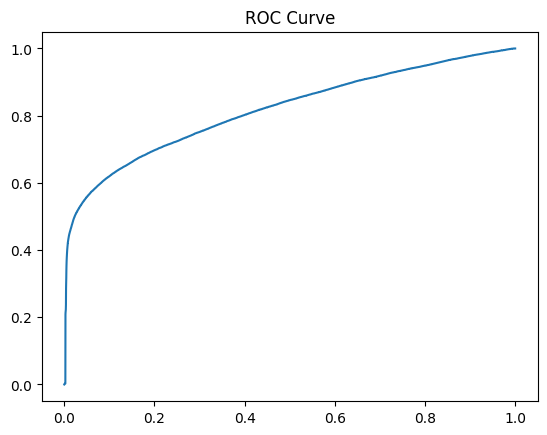

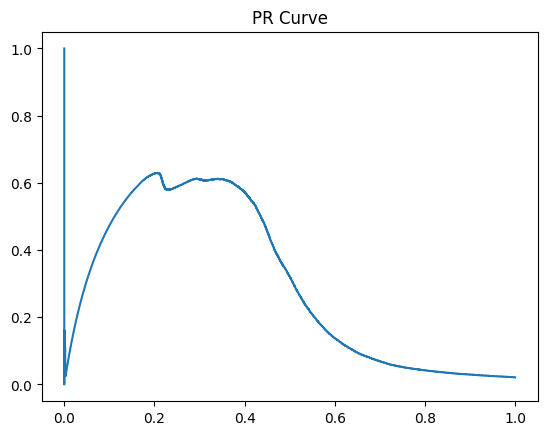

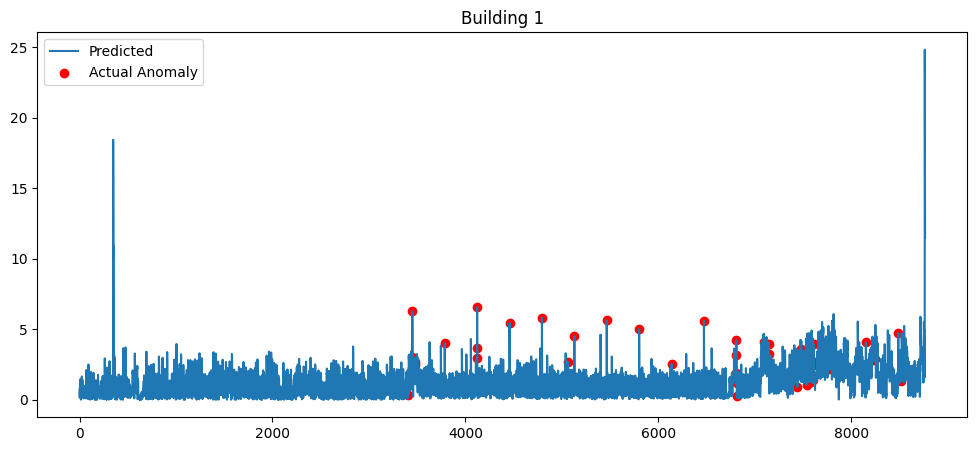

In [6]:
# =========================================================
# 0. IMPORTS
# =========================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.cuda.empty_cache()

# =========================================================
# 1. DATA PREPARATION (PHYSICS UNCHANGED)
# =========================================================
SEQ_LEN = 16

def prepare_data(path):
    df = pd.read_csv(path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id", "timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["hour"] = df["timestamp"].dt.hour
    df["dow"] = df["timestamp"].dt.dayofweek

    norm = (
        df[df["anomaly"] == 0]
        .groupby(["building_id", "dow", "hour"])["meter_log"]
        .agg(["median", "std"])
        .reset_index()
    )
    norm.columns = ["building_id", "dow", "hour", "h_med", "h_std"]
    df = df.merge(norm, on=["building_id", "dow", "hour"], how="left")

    df["h_med"] = df["h_med"].fillna(
        df.groupby("building_id")["meter_log"].transform("median")
    )

    df["temp_inertia"] = (
        df.groupby("building_id")["air_temperature"]
        .transform(lambda x: x.rolling(6, min_periods=1).mean())
    )

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    df["shock"] = df["meter_log"] - df["h_med"]
    df["shock_v"] = df.groupby("building_id")["shock"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock_v"].diff().fillna(0)

    df["shock_scaled"] = df.groupby("building_id")["shock"].transform(
        lambda x: (x - x.median()) /
        (x.quantile(0.75) - x.quantile(0.25) + 1e-6)
    )

    feat_cols = ["shock_scaled", "thermal_p", "kinetic_s", "air_temperature"]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], 0).fillna(0)

    le_b, le_s, le_u = LabelEncoder(), LabelEncoder(), LabelEncoder()
    df["b_idx"] = le_b.fit_transform(df["building_id"])
    df["s_idx"] = le_s.fit_transform(df["site_id"])
    df["u_idx"] = le_u.fit_transform(df["primary_use"])

    return df, feat_cols, le_b, le_s, le_u

# =========================================================
# 2. SEQUENCE WINDOWING
# =========================================================
def create_sequences(df, feat_cols):
    X, b, s, u, y, bid = [], [], [], [], [], []

    for building_id, group in df.groupby("building_id"):
        group = group.sort_values("timestamp")

        feats = group[feat_cols].values
        labels = group["anomaly"].values
        b_idx = group["b_idx"].values
        s_idx = group["s_idx"].values
        u_idx = group["u_idx"].values

        for i in range(len(group) - SEQ_LEN):
            X.append(feats[i:i+SEQ_LEN])
            y.append(labels[i+SEQ_LEN-1])
            b.append(b_idx[i+SEQ_LEN-1])
            s.append(s_idx[i+SEQ_LEN-1])
            u.append(u_idx[i+SEQ_LEN-1])
            bid.append(building_id)

    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(b),
        torch.tensor(s),
        torch.tensor(u),
        np.array(y),
        np.array(bid)
    )

# =========================================================
# 3. TEMPORAL TRANSFORMER
# =========================================================
class TemporalTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, 96)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=96,
            nhead=4,
            dim_feedforward=192,
            dropout=0.1,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.norm = nn.LayerNorm(96)

    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        return torch.nan_to_num(x)

# =========================================================
# 4. PIGD + TRANSFORMER WITH DIFFUSION
# =========================================================
class PIGD_Transformer(nn.Module):
    def __init__(self, inp, nb, ns, nu):
        super().__init__()

        self.temporal = TemporalTransformer(inp)

        self.b = nn.Embedding(nb, 64)
        self.s = nn.Embedding(ns, 16)
        self.u = nn.Embedding(nu, 16)
        self.t = nn.Sequential(nn.Linear(1, 32), nn.SiLU())

        self.proj = nn.Linear(96, 192)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(192),
                nn.Linear(192, 384),
                nn.SiLU(),
                nn.Linear(384, 192)
            ) for _ in range(4)
        ])

        self.out = nn.Linear(192, inp)

    def forward(self, x, t, b, s, u):
        x = self.temporal(x)

        te = self.t(t.float().unsqueeze(1)/100)
        ctx = torch.cat([self.b(b), self.s(s), self.u(u), te], dim=1)

        h = self.proj(x)
        for blk in self.blocks:
            h = h + blk(h)

        return torch.nan_to_num(self.out(h))

# =========================================================
# 5. TRAINING (NORMAL ONLY + DIFFUSION)
# =========================================================
def train_kfold(X, b, s, u, y, bid, nb, ns, nu):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    ensemble_scores = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n🔥 Fold {fold+1}")

        model = PIGD_Transformer(X.shape[2], nb, ns, nu).to(device)
        opt = optim.AdamW(model.parameters(), lr=1e-3)

        best_pr = 0
        patience = 5
        counter = 0

        # TRAIN ONLY NORMAL WINDOWS
        normal_mask = y[train_idx] == 0
        X_train = X[train_idx][normal_mask]
        b_train = b[train_idx][normal_mask]
        s_train = s[train_idx][normal_mask]
        u_train = u[train_idx][normal_mask]

        train_loader = DataLoader(
            TensorDataset(X_train, b_train, s_train, u_train),
            batch_size=512,
            shuffle=True
        )

        alphas = torch.linspace(1e-4, 0.02, 50).to(device)

        for epoch in range(25):
            model.train()
            for xb, bb, sb, ub in train_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                target = xb[:, -1, :]
                t = torch.randint(0, 50, (xb.size(0),), device=device)
                noise = torch.randn_like(target)
                alpha = alphas[t].unsqueeze(1)

                noisy = torch.sqrt(1-alpha)*target + torch.sqrt(alpha)*noise

                pred = model(xb, t, bb, sb, ub)
                loss = nn.MSELoss()(pred, target)

                if torch.isfinite(loss):
                    opt.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()

            # VALIDATION
            model.eval()
            val_loader = DataLoader(
                TensorDataset(X[val_idx], b[val_idx], s[val_idx], u[val_idx]),
                batch_size=512,
                shuffle=False
            )

            val_err = []
            with torch.no_grad():
                for xb, bb, sb, ub in val_loader:
                    xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)
                    t = torch.zeros(xb.size(0), device=device)
                    pred = model(xb, t, bb, sb, ub)

                    # PHYSICS WEIGHTED ERROR
                    err = (
                        torch.abs(pred[:,0]-xb[:,-1,0]) +
                        0.75*torch.abs(pred[:,2]-xb[:,-1,2]) +
                        0.5*torch.abs(pred[:,1]-xb[:,-1,1])
                    )

                    val_err.append(err.cpu())

            val_err = torch.cat(val_err).numpy()
            val_err = np.nan_to_num(val_err)

            pr = average_precision_score(y[val_idx], val_err)
            print(f"Epoch {epoch+1} | PR: {pr:.4f}")

            if pr > best_pr:
                best_pr = pr
                best_state = model.state_dict()
                counter = 0
            else:
                counter += 1

            if counter >= patience:
                print("Early stopping")
                break

        model.load_state_dict(best_state)

        # FULL INFERENCE
        full_loader = DataLoader(
            TensorDataset(X, b, s, u),
            batch_size=512,
            shuffle=False
        )

        fold_scores = []
        with torch.no_grad():
            for xb, bb, sb, ub in full_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)
                t = torch.zeros(xb.size(0), device=device)
                pred = model(xb, t, bb, sb, ub)

                err = (
                    torch.abs(pred[:,0]-xb[:,-1,0]) +
                    0.75*torch.abs(pred[:,2]-xb[:,-1,2]) +
                    0.5*torch.abs(pred[:,1]-xb[:,-1,1])
                )

                fold_scores.append(err.cpu())

        fold_scores = torch.cat(fold_scores).numpy()
        fold_scores = np.nan_to_num(fold_scores)

        ensemble_scores += fold_scores / 3

    return ensemble_scores

# =========================================================
# 6. EVALUATION
# =========================================================
def evaluate(scores, y, bid):

    scores = np.nan_to_num(scores)

    auc = roc_auc_score(y, scores)
    pr = average_precision_score(y, scores)

    thresh = np.percentile(scores, 95)
    preds = (scores > thresh).astype(int)

    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    fpr = np.sum((preds==1)&(y==0)) / np.sum(y==0)

    print("\n🏆 FINAL RESULTS")
    print("ROC-AUC :", auc)
    print("PR-AUC  :", pr)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TPR:", recall)
    print("FPR:", fpr)

    fpr_c, tpr_c, _ = roc_curve(y, scores)
    plt.plot(fpr_c, tpr_c)
    plt.title("ROC Curve")
    plt.show()

    p_c, r_c, _ = precision_recall_curve(y, scores)
    plt.plot(r_c, p_c)
    plt.title("PR Curve")
    plt.show()

    sample = bid[0]
    mask = (bid == sample)

    plt.figure(figsize=(12,5))
    plt.plot(scores[mask], label="Predicted")
    plt.scatter(np.where(y[mask]==1), scores[mask][y[mask]==1],
                color="red", label="Actual Anomaly")
    plt.legend()
    plt.title(f"Building {sample}")
    plt.show()

# =========================================================
# RUN
# =========================================================
path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"

df, feats, le_b, le_s, le_u = prepare_data(path)
X, b, s, u, y, bid = create_sequences(df, feats)

scores = train_kfold(
    X, b, s, u, y, bid,
    len(le_b.classes_),
    len(le_s.classes_),
    len(le_u.classes_)
)

evaluate(scores, y, bid)

Device: cuda

🔥 Fold 1
Epoch 1 | PR: 0.2938
Epoch 2 | PR: 0.2938
Epoch 3 | PR: 0.2938
Epoch 4 | PR: 0.2938
Epoch 5 | PR: 0.2938
Epoch 6 | PR: 0.2938
Early stopping

🔥 Fold 2
Epoch 1 | PR: 0.2957
Epoch 2 | PR: 0.2957
Epoch 3 | PR: 0.2957
Epoch 4 | PR: 0.2957
Epoch 5 | PR: 0.2957
Epoch 6 | PR: 0.2957
Early stopping

🔥 Fold 3
Epoch 1 | PR: 0.2918
Epoch 2 | PR: 0.2918
Epoch 3 | PR: 0.2918
Epoch 4 | PR: 0.2918
Epoch 5 | PR: 0.2918
Epoch 6 | PR: 0.2918
Early stopping

🏆 FINAL RESULTS
ROC-AUC : 0.817156946503979
PR-AUC  : 0.29370170409032725
Precision: 0.22880375651377197
Recall: 0.5387519551264764
TPR: 0.5387519551264764
FPR: 0.03939651722548168


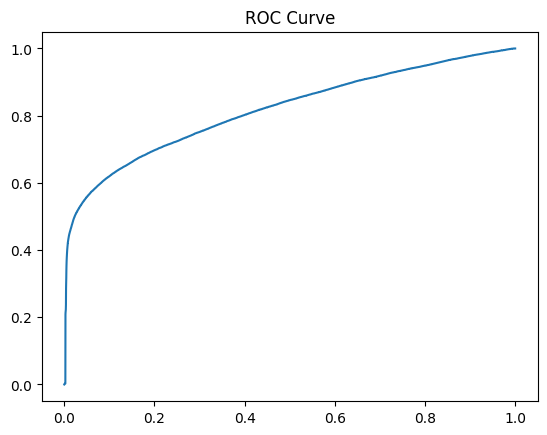

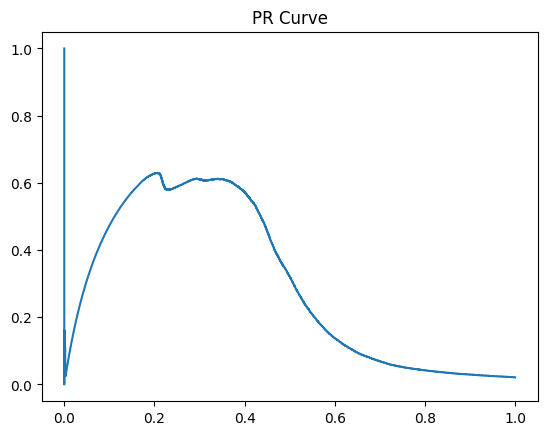

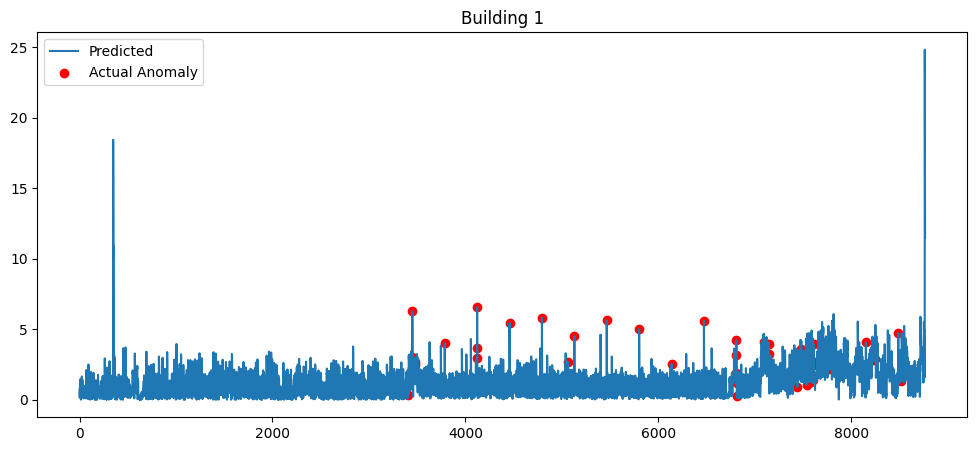

In [7]:
# =========================================================
# 0. IMPORTS
# =========================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.cuda.empty_cache()

# =========================================================
# 1. DATA PREPARATION
# =========================================================
SEQ_LEN = 16

def prepare_data(path):
    df = pd.read_csv(path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id", "timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["hour"] = df["timestamp"].dt.hour
    df["dow"] = df["timestamp"].dt.dayofweek

    norm = (
        df[df["anomaly"] == 0]
        .groupby(["building_id", "dow", "hour"])["meter_log"]
        .agg(["median", "std"])
        .reset_index()
    )
    norm.columns = ["building_id", "dow", "hour", "h_med", "h_std"]
    df = df.merge(norm, on=["building_id", "dow", "hour"], how="left")

    df["h_med"] = df["h_med"].fillna(
        df.groupby("building_id")["meter_log"].transform("median")
    )

    df["temp_inertia"] = (
        df.groupby("building_id")["air_temperature"]
        .transform(lambda x: x.rolling(6, min_periods=1).mean())
    )

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    df["shock"] = df["meter_log"] - df["h_med"]
    df["shock_v"] = df.groupby("building_id")["shock"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock_v"].diff().fillna(0)

    df["shock_scaled"] = df.groupby("building_id")["shock"].transform(
        lambda x: (x - x.median()) /
        (x.quantile(0.75) - x.quantile(0.25) + 1e-6)
    )

    feat_cols = ["shock_scaled", "thermal_p", "kinetic_s", "air_temperature"]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], 0).fillna(0)

    le_b, le_s, le_u = LabelEncoder(), LabelEncoder(), LabelEncoder()
    df["b_idx"] = le_b.fit_transform(df["building_id"])
    df["s_idx"] = le_s.fit_transform(df["site_id"])
    df["u_idx"] = le_u.fit_transform(df["primary_use"])

    return df, feat_cols, le_b, le_s, le_u

# =========================================================
# 2. SEQUENCE WINDOWING
# =========================================================
def create_sequences(df, feat_cols):
    X, b, s, u, y, bid = [], [], [], [], [], []

    for building_id, group in df.groupby("building_id"):
        group = group.sort_values("timestamp")

        feats = group[feat_cols].values
        labels = group["anomaly"].values
        b_idx = group["b_idx"].values
        s_idx = group["s_idx"].values
        u_idx = group["u_idx"].values

        for i in range(len(group) - SEQ_LEN):
            X.append(feats[i:i+SEQ_LEN])
            y.append(labels[i+SEQ_LEN-1])
            b.append(b_idx[i+SEQ_LEN-1])
            s.append(s_idx[i+SEQ_LEN-1])
            u.append(u_idx[i+SEQ_LEN-1])
            bid.append(building_id)

    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(b),
        torch.tensor(s),
        torch.tensor(u),
        np.array(y),
        np.array(bid)
    )

# =========================================================
# 3. TEMPORAL TRANSFORMER
# =========================================================
class TemporalTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, 96)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=96,
            nhead=4,
            dim_feedforward=192,
            dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.norm = nn.LayerNorm(96)

    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        return torch.nan_to_num(x)

# =========================================================
# 4. PIGD + TRANSFORMER
# =========================================================
class PIGD_Transformer(nn.Module):
    def __init__(self, inp, nb, ns, nu):
        super().__init__()

        self.temporal = TemporalTransformer(inp)

        self.b = nn.Embedding(nb, 64)
        self.s = nn.Embedding(ns, 16)
        self.u = nn.Embedding(nu, 16)
        self.t = nn.Sequential(nn.Linear(1, 32), nn.SiLU())

        self.proj = nn.Linear(96, 192)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(192),
                nn.Linear(192, 384),
                nn.SiLU(),
                nn.Linear(384, 192)
            ) for _ in range(4)
        ])

        self.out = nn.Linear(192, inp)

    def forward(self, x, t, b, s, u):
        x = self.temporal(x)

        te = self.t(t.float().unsqueeze(1)/100)
        ctx = torch.cat([self.b(b), self.s(s), self.u(u), te], dim=1)

        h = self.proj(x)
        for blk in self.blocks:
            h = h + blk(h)

        return torch.nan_to_num(self.out(h))

# =========================================================
# 5. TRAINING WITH REAL DIFFUSION
# =========================================================
def train_kfold(X, b, s, u, y, bid, nb, ns, nu):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    ensemble_scores = np.zeros(len(y))

    alphas = torch.linspace(1e-4, 0.02, 50).to(device)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n🔥 Fold {fold+1}")

        model = PIGD_Transformer(X.shape[2], nb, ns, nu).to(device)
        opt = optim.AdamW(model.parameters(), lr=1e-3)

        best_pr = 0
        patience = 5
        counter = 0

        normal_mask = y[train_idx] == 0
        X_train = X[train_idx][normal_mask]
        b_train = b[train_idx][normal_mask]
        s_train = s[train_idx][normal_mask]
        u_train = u[train_idx][normal_mask]

        train_loader = DataLoader(
            TensorDataset(X_train, b_train, s_train, u_train),
            batch_size=512,
            shuffle=True
        )

        for epoch in range(25):
            model.train()
            for xb, bb, sb, ub in train_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                target = xb[:, -1, :]
                t = torch.randint(0, 50, (xb.size(0),), device=device)

                noise = torch.randn_like(target)
                alpha = alphas[t].unsqueeze(1)

                noisy_last = torch.sqrt(1 - alpha) * target + torch.sqrt(alpha) * noise
                xb_noisy = xb.clone()
                xb_noisy[:, -1, :] = noisy_last

                pred = model(xb_noisy, t, bb, sb, ub)

                loss = nn.MSELoss()(pred, target)

                if torch.isfinite(loss):
                    opt.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()

            # VALIDATION
            model.eval()
            val_loader = DataLoader(
                TensorDataset(X[val_idx], b[val_idx], s[val_idx], u[val_idx]),
                batch_size=512,
                shuffle=False
            )

            val_err = []
            with torch.no_grad():
                for xb, bb, sb, ub in val_loader:
                    xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                    t = torch.zeros(xb.size(0), device=device)
                    pred = model(xb, t, bb, sb, ub)

                    err = (
                        torch.abs(pred[:,0]-xb[:,-1,0]) +
                        0.75*torch.abs(pred[:,2]-xb[:,-1,2]) +
                        0.5*torch.abs(pred[:,1]-xb[:,-1,1])
                    )

                    val_err.append(err.cpu())

            val_err = torch.cat(val_err).numpy()
            val_err = np.nan_to_num(val_err)

            pr = average_precision_score(y[val_idx], val_err)
            print(f"Epoch {epoch+1} | PR: {pr:.4f}")

            if pr > best_pr:
                best_pr = pr
                best_state = model.state_dict()
                counter = 0
            else:
                counter += 1

            if counter >= patience:
                print("Early stopping")
                break

        model.load_state_dict(best_state)

        # FULL INFERENCE
        full_loader = DataLoader(
            TensorDataset(X, b, s, u),
            batch_size=512,
            shuffle=False
        )

        fold_scores = []
        with torch.no_grad():
            for xb, bb, sb, ub in full_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)
                t = torch.zeros(xb.size(0), device=device)
                pred = model(xb, t, bb, sb, ub)

                err = (
                    torch.abs(pred[:,0]-xb[:,-1,0]) +
                    0.75*torch.abs(pred[:,2]-xb[:,-1,2]) +
                    0.5*torch.abs(pred[:,1]-xb[:,-1,1])
                )

                fold_scores.append(err.cpu())

        fold_scores = torch.cat(fold_scores).numpy()
        fold_scores = np.nan_to_num(fold_scores)

        ensemble_scores += fold_scores / 3

    return ensemble_scores

# =========================================================
# 6. EVALUATION
# =========================================================
def evaluate(scores, y, bid):

    scores = np.nan_to_num(scores)

    auc = roc_auc_score(y, scores)
    pr = average_precision_score(y, scores)

    thresh = np.percentile(scores, 95)
    preds = (scores > thresh).astype(int)

    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    fpr = np.sum((preds==1)&(y==0)) / np.sum(y==0)

    print("\n🏆 FINAL RESULTS")
    print("ROC-AUC :", auc)
    print("PR-AUC  :", pr)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TPR:", recall)
    print("FPR:", fpr)

    fpr_c, tpr_c, _ = roc_curve(y, scores)
    plt.plot(fpr_c, tpr_c)
    plt.title("ROC Curve")
    plt.show()

    p_c, r_c, _ = precision_recall_curve(y, scores)
    plt.plot(r_c, p_c)
    plt.title("PR Curve")
    plt.show()

    sample = bid[0]
    mask = (bid == sample)

    plt.figure(figsize=(12,5))
    plt.plot(scores[mask], label="Predicted")
    plt.scatter(np.where(y[mask]==1), scores[mask][y[mask]==1],
                color="red", label="Actual Anomaly")
    plt.legend()
    plt.title(f"Building {sample}")
    plt.show()

# =========================================================
# RUN
# =========================================================
path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"

df, feats, le_b, le_s, le_u = prepare_data(path)
X, b, s, u, y, bid = create_sequences(df, feats)

scores = train_kfold(
    X, b, s, u, y, bid,
    len(le_b.classes_),
    len(le_s.classes_),
    len(le_u.classes_)
)

evaluate(scores, y, bid)

Device: cuda

🔥 Fold 1
Epoch 1 | PR: 0.2938
Epoch 2 | PR: 0.2938
Epoch 3 | PR: 0.2938
Epoch 4 | PR: 0.2938
Epoch 5 | PR: 0.2938
Epoch 6 | PR: 0.2938
Early stopping

🔥 Fold 2
Epoch 1 | PR: 0.2957
Epoch 2 | PR: 0.2957
Epoch 3 | PR: 0.2957
Epoch 4 | PR: 0.2957
Epoch 5 | PR: 0.2957
Epoch 6 | PR: 0.2957
Early stopping

🔥 Fold 3
Epoch 1 | PR: 0.2918
Epoch 2 | PR: 0.2918
Epoch 3 | PR: 0.2918
Epoch 4 | PR: 0.2918
Epoch 5 | PR: 0.2918
Epoch 6 | PR: 0.2918
Early stopping

🏆 FINAL RESULTS
ROC-AUC : 0.817156946503979
PR-AUC  : 0.29370170409032725
Precision: 0.22880375651377197
Recall: 0.5387519551264764
TPR: 0.5387519551264764
FPR: 0.03939651722548168


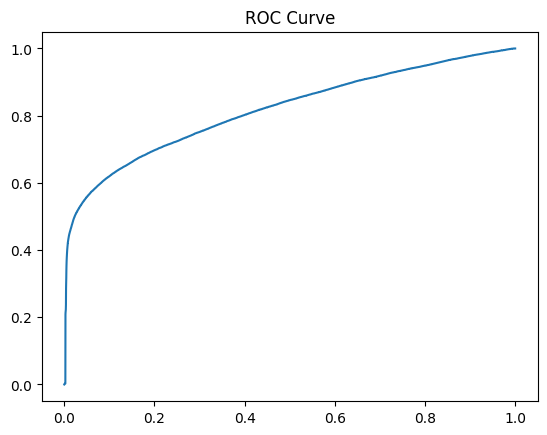

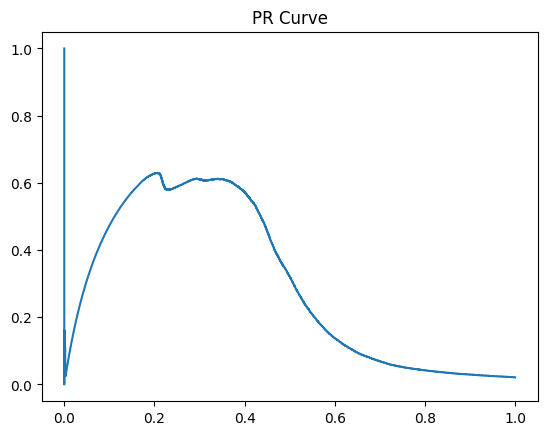

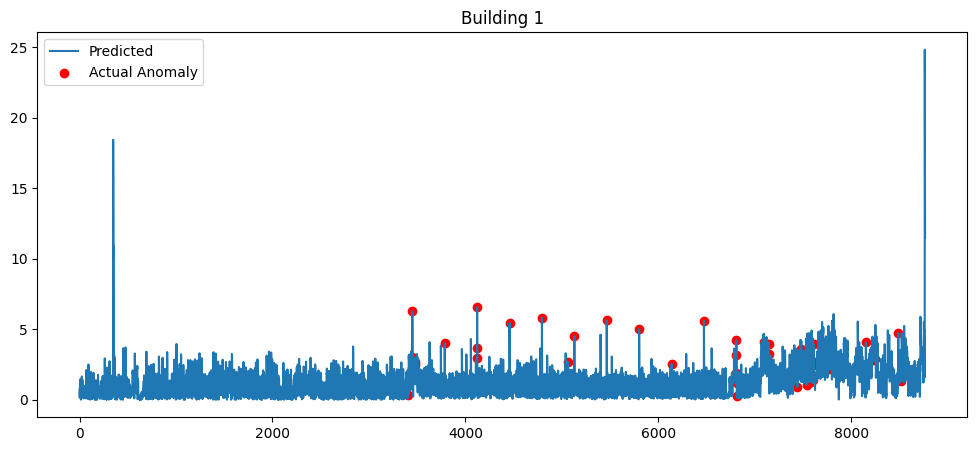

In [8]:
# =========================================================
# 0. IMPORTS
# =========================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.cuda.empty_cache()

# =========================================================
# 1. DATA PREPARATION
# =========================================================
SEQ_LEN = 16
DIFF_T = 15   # diffusion timestep for inference consistency
DIFF_STEPS = 50

def prepare_data(path):
    df = pd.read_csv(path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["building_id", "timestamp"])

    df["meter_log"] = np.log1p(df["meter_reading"])
    df["hour"] = df["timestamp"].dt.hour
    df["dow"] = df["timestamp"].dt.dayofweek

    norm = (
        df[df["anomaly"] == 0]
        .groupby(["building_id", "dow", "hour"])["meter_log"]
        .agg(["median", "std"])
        .reset_index()
    )
    norm.columns = ["building_id", "dow", "hour", "h_med", "h_std"]
    df = df.merge(norm, on=["building_id", "dow", "hour"], how="left")

    df["h_med"] = df["h_med"].fillna(
        df.groupby("building_id")["meter_log"].transform("median")
    )

    df["temp_inertia"] = (
        df.groupby("building_id")["air_temperature"]
        .transform(lambda x: x.rolling(6, min_periods=1).mean())
    )

    df["thermal_p"] = df["air_temperature"] - df["temp_inertia"]

    df["shock"] = df["meter_log"] - df["h_med"]
    df["shock_v"] = df.groupby("building_id")["shock"].diff().fillna(0)
    df["kinetic_s"] = df.groupby("building_id")["shock_v"].diff().fillna(0)

    df["shock_scaled"] = df.groupby("building_id")["shock"].transform(
        lambda x: (x - x.median()) /
        (x.quantile(0.75) - x.quantile(0.25) + 1e-6)
    )

    feat_cols = ["shock_scaled", "thermal_p", "kinetic_s", "air_temperature"]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], 0).fillna(0)

    le_b, le_s, le_u = LabelEncoder(), LabelEncoder(), LabelEncoder()
    df["b_idx"] = le_b.fit_transform(df["building_id"])
    df["s_idx"] = le_s.fit_transform(df["site_id"])
    df["u_idx"] = le_u.fit_transform(df["primary_use"])

    return df, feat_cols, le_b, le_s, le_u

# =========================================================
# 2. SEQUENCE WINDOWING
# =========================================================
def create_sequences(df, feat_cols):
    X, b, s, u, y, bid = [], [], [], [], [], []

    for building_id, group in df.groupby("building_id"):
        group = group.sort_values("timestamp")

        feats = group[feat_cols].values
        labels = group["anomaly"].values
        b_idx = group["b_idx"].values
        s_idx = group["s_idx"].values
        u_idx = group["u_idx"].values

        for i in range(len(group) - SEQ_LEN):
            X.append(feats[i:i+SEQ_LEN])
            y.append(labels[i+SEQ_LEN-1])
            b.append(b_idx[i+SEQ_LEN-1])
            s.append(s_idx[i+SEQ_LEN-1])
            u.append(u_idx[i+SEQ_LEN-1])
            bid.append(building_id)

    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(b),
        torch.tensor(s),
        torch.tensor(u),
        np.array(y),
        np.array(bid)
    )

# =========================================================
# 3. TEMPORAL TRANSFORMER
# =========================================================
class TemporalTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, 96)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=96,
            nhead=4,
            dim_feedforward=192,
            dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.norm = nn.LayerNorm(96)

    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        return torch.nan_to_num(x)

# =========================================================
# 4. PIGD + TRANSFORMER
# =========================================================
class PIGD_Transformer(nn.Module):
    def __init__(self, inp, nb, ns, nu):
        super().__init__()

        self.temporal = TemporalTransformer(inp)

        self.b = nn.Embedding(nb, 64)
        self.s = nn.Embedding(ns, 16)
        self.u = nn.Embedding(nu, 16)
        self.t = nn.Sequential(nn.Linear(1, 32), nn.SiLU())

        self.proj = nn.Linear(96, 192)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(192),
                nn.Linear(192, 384),
                nn.SiLU(),
                nn.Linear(384, 192)
            ) for _ in range(4)
        ])

        self.out = nn.Linear(192, inp)

    def forward(self, x, t, b, s, u):
        x = self.temporal(x)

        te = self.t(t.float().unsqueeze(1)/100)
        ctx = torch.cat([self.b(b), self.s(s), self.u(u), te], dim=1)

        h = self.proj(x)
        for blk in self.blocks:
            h = h + blk(h)

        return torch.nan_to_num(self.out(h))

# =========================================================
# 5. TRAINING + VALIDATION + ENSEMBLE
# =========================================================
def train_kfold(X, b, s, u, y, bid, nb, ns, nu):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    ensemble_scores = np.zeros(len(y))

    alphas = torch.linspace(1e-4, 0.02, DIFF_STEPS).to(device)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n🔥 Fold {fold+1}")

        model = PIGD_Transformer(X.shape[2], nb, ns, nu).to(device)
        opt = optim.AdamW(model.parameters(), lr=1e-3)

        best_pr = 0
        patience = 5
        counter = 0

        normal_mask = y[train_idx] == 0
        X_train = X[train_idx][normal_mask]
        b_train = b[train_idx][normal_mask]
        s_train = s[train_idx][normal_mask]
        u_train = u[train_idx][normal_mask]

        train_loader = DataLoader(
            TensorDataset(X_train, b_train, s_train, u_train),
            batch_size=512,
            shuffle=True
        )

        for epoch in range(25):
            model.train()
            for xb, bb, sb, ub in train_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                target = xb[:, -1, :]
                t = torch.randint(0, DIFF_STEPS, (xb.size(0),), device=device)

                noise = torch.randn_like(target)
                alpha = alphas[t].unsqueeze(1)

                noisy_last = torch.sqrt(1 - alpha) * target + torch.sqrt(alpha) * noise
                xb_noisy = xb.clone()
                xb_noisy[:, -1, :] = noisy_last

                pred = model(xb_noisy, t, bb, sb, ub)
                loss = nn.MSELoss()(pred, target)

                if torch.isfinite(loss):
                    opt.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()

            # VALIDATION WITH SAME DIFFUSION
            model.eval()
            val_loader = DataLoader(
                TensorDataset(X[val_idx], b[val_idx], s[val_idx], u[val_idx]),
                batch_size=512,
                shuffle=False
            )

            val_err = []
            with torch.no_grad():
                for xb, bb, sb, ub in val_loader:
                    xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                    target = xb[:, -1, :]
                    t = torch.full((xb.size(0),), DIFF_T, device=device)

                    noise = torch.randn_like(target)
                    alpha = alphas[t].unsqueeze(1)

                    noisy_last = torch.sqrt(1 - alpha) * target + torch.sqrt(alpha) * noise
                    xb_noisy = xb.clone()
                    xb_noisy[:, -1, :] = noisy_last

                    pred = model(xb_noisy, t, bb, sb, ub)

                    err = (
                        torch.abs(pred[:,0]-target[:,0]) +
                        0.75*torch.abs(pred[:,2]-target[:,2]) +
                        0.5*torch.abs(pred[:,1]-target[:,1])
                    )

                    val_err.append(err.cpu())

            val_err = torch.cat(val_err).numpy()
            val_err = np.nan_to_num(val_err)

            pr = average_precision_score(y[val_idx], val_err)
            print(f"Epoch {epoch+1} | PR: {pr:.4f}")

            if pr > best_pr:
                best_pr = pr
                best_state = model.state_dict()
                counter = 0
            else:
                counter += 1

            if counter >= patience:
                print("Early stopping")
                break

        model.load_state_dict(best_state)

        # FULL INFERENCE WITH DIFFUSION
        full_loader = DataLoader(
            TensorDataset(X, b, s, u),
            batch_size=512,
            shuffle=False
        )

        fold_scores = []
        with torch.no_grad():
            for xb, bb, sb, ub in full_loader:
                xb, bb, sb, ub = xb.to(device), bb.to(device), sb.to(device), ub.to(device)

                target = xb[:, -1, :]
                t = torch.full((xb.size(0),), DIFF_T, device=device)

                noise = torch.randn_like(target)
                alpha = alphas[t].unsqueeze(1)

                noisy_last = torch.sqrt(1 - alpha) * target + torch.sqrt(alpha) * noise
                xb_noisy = xb.clone()
                xb_noisy[:, -1, :] = noisy_last

                pred = model(xb_noisy, t, bb, sb, ub)

                err = (
                    torch.abs(pred[:,0]-target[:,0]) +
                    0.75*torch.abs(pred[:,2]-target[:,2]) +
                    0.5*torch.abs(pred[:,1]-target[:,1])
                )

                fold_scores.append(err.cpu())

        fold_scores = torch.cat(fold_scores).numpy()
        fold_scores = np.nan_to_num(fold_scores)

        ensemble_scores += fold_scores / 3

    return ensemble_scores

# =========================================================
# 6. EVALUATION
# =========================================================
def evaluate(scores, y, bid):

    scores = np.nan_to_num(scores)

    auc = roc_auc_score(y, scores)
    pr = average_precision_score(y, scores)

    thresh = np.percentile(scores, 95)
    preds = (scores > thresh).astype(int)

    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    fpr = np.sum((preds==1)&(y==0)) / np.sum(y==0)

    print("\n🏆 FINAL RESULTS")
    print("ROC-AUC :", auc)
    print("PR-AUC  :", pr)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TPR:", recall)
    print("FPR:", fpr)

    fpr_c, tpr_c, _ = roc_curve(y, scores)
    plt.plot(fpr_c, tpr_c)
    plt.title("ROC Curve")
    plt.show()

    p_c, r_c, _ = precision_recall_curve(y, scores)
    plt.plot(r_c, p_c)
    plt.title("PR Curve")
    plt.show()

    sample = bid[0]
    mask = (bid == sample)

    plt.figure(figsize=(12,5))
    plt.plot(scores[mask], label="Predicted")
    plt.scatter(np.where(y[mask]==1), scores[mask][y[mask]==1],
                color="red", label="Actual Anomaly")
    plt.legend()
    plt.title(f"Building {sample}")
    plt.show()

# =========================================================
# RUN
# =========================================================
path = "/kaggle/input/competitions/energy-anomaly-detection/train_features.csv"

df, feats, le_b, le_s, le_u = prepare_data(path)
X, b, s, u, y, bid = create_sequences(df, feats)

scores = train_kfold(
    X, b, s, u, y, bid,
    len(le_b.classes_),
    len(le_s.classes_),
    len(le_u.classes_)
)

evaluate(scores, y, bid)